## TODO

- [x] see if there are properties outside of the district
- [x] outliers
- [x] try bagging

## Notes on the domain

Xindian district: an inner city district in the southern part of New Taipei City in Taiwan.
Each row is a sale.

- There are 5 mrt stations in Xindian.
- MRT = Mass Rapid Transit/Metro Rail Transit

In [1]:
from ucimlrepo import fetch_ucirepo
import pprint
from IPython.display import Markdown, display

# fetch dataset
real_estate_valuation = fetch_ucirepo(id=477)

# data (as pandas dataframes)
X = real_estate_valuation.data.features
y = real_estate_valuation.data.targets

# metadata
print(real_estate_valuation.metadata)

# variable information
print(real_estate_valuation.variables)

{'uci_id': 477, 'name': 'Real Estate Valuation', 'repository_url': 'https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set', 'data_url': 'https://archive.ics.uci.edu/static/public/477/data.csv', 'abstract': 'The real estate valuation is a regression problem. The market historical data set of real estate valuation are collected from Sindian Dist., New Taipei City, Taiwan. ', 'area': 'Business', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 414, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y house price of unit area'], 'index_col': ['No'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C5J30W', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 373, 'type': 'NATIVE', 'title': 'Building real estate valuation models with comparative approach through case-based reasoning', 'authors': 'I. Yeh

## notes on the data structure offered by uciml

- data: im only interested to features (X) and targets (y)
- metadata: a dict containing many infos on the task.
- variables: df where each entry is a column of X $\cup$ y. info inside it is already included in metadata.additional_info.variable_info

In [2]:
real_estate_valuation.keys()

dict_keys(['data', 'metadata', 'variables'])

In [5]:
real_estate_valuation.data.keys()

dict_keys(['ids', 'features', 'targets', 'original', 'headers'])

In [15]:
real_estate_valuation.data.ids  # just an index starting from one
real_estate_valuation.data.features  # X, already cleaned. column names are formatted like "X{i} {feature_name}"
real_estate_valuation.data.targets  # y
real_estate_valuation.data.original  # ids + X + y

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


In [ ]:
real_estate_valuation.data.headers

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='str')

In [2]:
real_estate_valuation.metadata

{'uci_id': 477,
 'name': 'Real Estate Valuation',
 'repository_url': 'https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set',
 'data_url': 'https://archive.ics.uci.edu/static/public/477/data.csv',
 'abstract': 'The real estate valuation is a regression problem. The market historical data set of real estate valuation are collected from Sindian Dist., New Taipei City, Taiwan. ',
 'area': 'Business',
 'tasks': ['Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 414,
 'num_features': 6,
 'feature_types': ['Integer', 'Real'],
 'demographics': [],
 'target_col': ['Y house price of unit area'],
 'index_col': ['No'],
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2018,
 'last_updated': 'Mon Feb 26 2024',
 'dataset_doi': '10.24432/C5J30W',
 'creators': ['I-Cheng Yeh'],
 'intro_paper': {'ID': 373,
  'type': 'NATIVE',
  'title': 'Building real estate valuation models with comparative approach through case-based reason

In [16]:
real_estate_valuation.variables

,name,role,type,demographic,description,units,missing_values
0,No,ID,Integer,None,NaN,NaN,no
1,X1 transaction date,Feature,Continuous,None,"for example, 2013.250=2013 March, 2013.500=201...",NaN,no
2,X2 house age,Feature,Continuous,None,NaN,year,no
3,X3 distance to the nearest MRT station,Feature,Continuous,None,NaN,meter,no
4,X4 number of convenience stores,Feature,Integer,None,number of convenience stores in the living cir...,integer,no
5,X5 latitude,Feature,Continuous,None,"geographic coordinate, latitude",degree,no
6,X6 longitude,Feature,Continuous,None,"geographic coordinate, longitude",degree,no
7,Y house price of unit area,Target,Continuous,None,"10000 New Taiwan Dollar/Ping, where Ping is a ...",10000 New Taiwan Dollar/Ping,no


In [18]:
list(real_estate_valuation.variables["description"])

[nan,
 'for example, 2013.250=2013 March, 2013.500=2013 June, etc.',
 nan,
 nan,
 'number of convenience stores in the living circle on foot',
 'geographic coordinate, latitude',
 'geographic coordinate, longitude',
 '10000 New Taiwan Dollar/Ping, where Ping is a local unit, 1 Ping = 3.3 meter squared']

In [ ]:
# removed from nb but I like how I formatted it
Markdown(
    """, 
""".join(
        [
            f"- $w_{n+1} = {coef:.2f}$ ({name})"
            for n, (name, coef) in enumerate(zip(X.columns, linear_regression.coef_[0]))
        ]
    )
)

- $w_1 = 5.91$ (X1 transaction date), 
- $w_2 = -0.27$ (X2 house age), 
- $w_3 = -0.00$ (X3 distance to the nearest MRT station), 
- $w_4 = 1.18$ (X4 number of convenience stores), 
- $w_5 = 191.06$ (X5 latitude), 
- $w_6 = -7.70$ (X6 longitude)

## `MLPRegressor` implementation



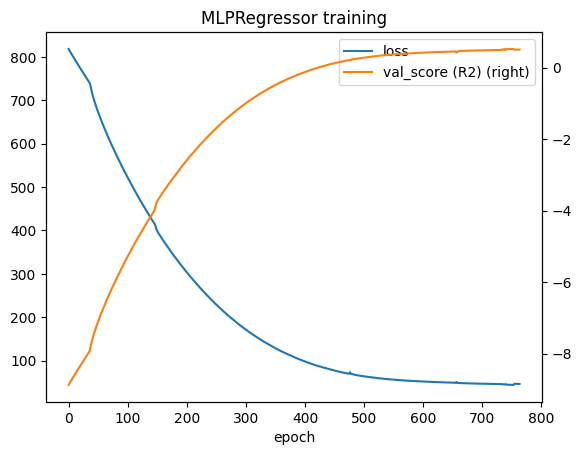

In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(6,),
    activation="logistic",
    batch_size=16,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=10, # patience
    random_state=RANDOM_STATE,
)
mlp.fit(X_train, y_train.values.ravel())

pd.DataFrame({"loss": mlp.loss_curve_, "val_score (R2)": mlp.validation_scores_}).plot(
    title="MLPRegressor training", xlabel="epoch", secondary_y="val_score (R2)"
)
plt.show()

## Colab server

training di mlfnn con 1 hidden layer a 6 neuroni ci mette 9.9 secondi (500 epoch, batchsize 16) su macbook e 1min su colab server. A quanto pare è questione di overhead e aumentando dim dataset e NN colab dovrebbe recuperare.

training a mlfnn with 1 hidden layer with 6 neurons takes ~9.9 seconds (500 epochs, batchsize 16) on a macbook, while it takes 1min on a colab server, Apparently there is an overhead which should fade out as dataset and NN get bigger.